# **Loan Approval Explainability Analysis**


- Part 1: Data Preparation
- Part 2: Model Building
- Part 3: SHAP Explanations (Begin Assignment 5.1)

## **Part 1: Data Preparation**

In [1]:
import os

# Get current working directory
dataset_path = os.getcwd()

In [2]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv(dataset_path + "/loan_approval_biased.csv")

# data exploration
df.info()  # Check for missing values and data types
print(df.head(20))
df.describe()

# Print the counts
#Count the number of males and females in the dataset
gender_counts = df['Gender'].value_counts()

# Print the counts
print("\nCounts of each gender in the dataset")
print(gender_counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    int64  
 9   Loan_Amount_Term   614 non-null    int64  
 10  Credit_History     614 non-null    int64  
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    object 
dtypes: float64(1), int64(9), object(3)
memory usage: 62.5+ KB
     Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0   LP002317    Male        1           3

### **Prepare Data for Logistic Regression:**

- Convert Loan_Status to binary (1 for Y, 0 for N)
- Convert Gender column to binary (1 for Male, 0 for Female)
- Define the preprocessor with OneHotEncoder for remaining categorical features


In [3]:
# Convert Loan_Status to binary (1 for Y, 0 for N)
df['Loan_Status'] = df['Loan_Status'].apply(lambda x: 1 if x == 'Y' else 0)

# Define categorical and numerical columns
categorical_columns = ['Married', 'Dependents', 'Self_Employed', 'Property_Area','Gender']
numerical_columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# Convert Gender column to binary (1 for Male, 0 for Female)
df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

# Define the preprocessor with OneHotEncoder for remaining categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ])

# Split the data into features and target
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# Apply the preprocessor on the full dataset
X_transformed = preprocessor.fit_transform(X)

# Convert the transformed data back into a df
transformed_feature_names = preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(X_transformed, columns=transformed_feature_names)

# Display the transformed data
print(X_transformed_df.head())



   cat__Married_0  cat__Married_1  cat__Dependents_0  cat__Dependents_1  \
0             0.0             1.0                0.0                0.0   
1             0.0             1.0                1.0                0.0   
2             0.0             1.0                0.0                0.0   
3             0.0             1.0                1.0                0.0   
4             1.0             0.0                0.0                1.0   

   cat__Dependents_2  cat__Dependents_3  cat__Self_Employed_0  \
0                0.0                1.0                   1.0   
1                0.0                0.0                   1.0   
2                0.0                1.0                   1.0   
3                0.0                0.0                   0.0   
4                0.0                0.0                   1.0   

   cat__Self_Employed_1  cat__Property_Area_0  cat__Property_Area_1  \
0                   0.0                   1.0                   0.0   
1               

In [4]:
#  Count the number of approved loans for each gender
# Filter for approved loans
approved_loans = df[df['Loan_Status'] == 1]

gender_approval_counts = approved_loans['Gender'].value_counts()

print(gender_approval_counts)

Gender
1    217
0      3
Name: count, dtype: int64


## **Part 2: Model Building**

In [5]:
# stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the preprocessor on training data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Create the pipeline with a logistic regression model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=10000))
])

# Fit the model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['Married', 'Dependents',
                                                   'Self_Employed',
                                                   'Property_Area', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History'])])),
                ('classifier', LogisticRegression(max_iter=10000))])

In [6]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9106
Precision: 0.9231
Recall: 0.8182
F1 Score: 0.8675


**Expected Output:**

- Logistic regression model should fit to the training data successfully.


*********

# **Begin Assignment 5.1**

## In this exercise, you will analyze the loan approval dataset and utilize SHAP to understand feature contributions to model predictions. The goal is to interpret how specific features affect decisions and reflect on the ethical implications of such models.


## **Part 3: SHAP Explanations**

(all output and responses should placed in 5.1 exercise document)

In [7]:
# Explaining model predictions using SHAP
# Take a sample of the training data for SHAP
X_sample = shap.sample(X_train, 100)

# Create the SHAP explainer
explainer = shap.Explainer(model.predict_proba, X_sample)

# Get SHAP values for the test set
shap_values = explainer(X_test)


### **Question 1a. Use SHAP to understand how individual features contribute to the prediction for a specific data point with a force plot that visualizes the feature contributions for a particular class.**

#### <b> Instructions </b>
- Generate the <b> SHAP force plot </b> for the first data point in your test set using the SHAP values.
- The force plot should explain how individual features contribute to pushing the model's prediction towards or away from <b> class 1 </b>.
- Make sure to use SHAP values corresponding to class 1 for the <b> first data point </b> in the test set.


In [8]:
# Javascript required for force plot
shap.initjs()

# Force plot
shap.force_plot(
    base_value=shap_values[0, :, 1].base_values, 
    shap_values=shap_values[0, :, 1].values, 
    features=X_test.iloc[0]
)

### **Question 1b. Which features are pushing the prediction towards class 1? Which features are pushing the prediction away from class 1?**

Based on the SHAP force plot, here is the breakdown of how the features are influencing the prediction:

Pushing the prediction towards class 1 (approval)
The featues pushing tjhe prediction higher are presented by the red arrows pointing to the right. The only major feature increasing their chance of approval is the Credit_gistory (having the value of 1)

The features pushing the prediction lower are represented by the blue arrows pointing to the left. The most significant features dragging this applicant's score down to 0.00 are: Gender (value = 0), ApplicantIncome (value = 2,500), and Property_Area (value = 2). The size of the arrow indicates the strength of the push. in means that the most negative impact isGender that has the largest blue block.

### **Question 2a. Create a bar plot that displays the SHAP values (feature contributions) for the second data point and SHAP values for class 1. The bar plot will show how much each feature contributes to the model's prediction for class 1, with the features ranked by their contribution.)**

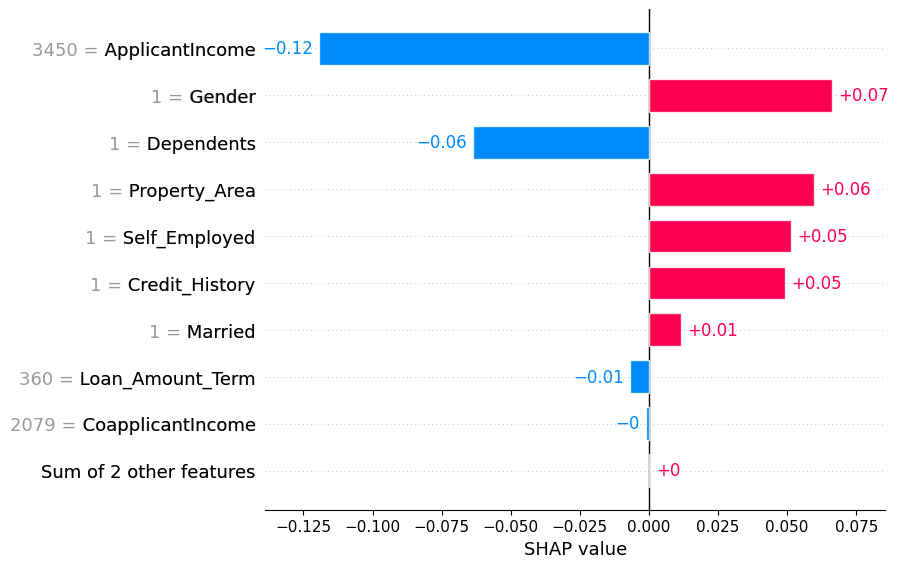

In [9]:
# SHAP Bar plot
shap.plots.bar(shap_values[1, :, 1])

### **Question 2b. Which feature had the greatest influence on the prediction for this data point? Were most features pushing the prediction toward or away from class 1? Are there any surprising variables that are influencing the prediction?**

**Which feature had the greatest influence on the prediction for this data point?**

The feature with the greatest influence is ApplicantIncome. It sits at the very top of the chart with the largest bar (an absolute SHAP value of 0.12). For this specific applicant, their income of 3450 had a strong negative impact (shown by the blue color), significantly pushing the model's prediction away from class 1 (denial).

**Were most features pushing the prediction toward or away from class 1?**

Most features were pushing the prediction toward class 1 (approval). If you count the bars, there are five red bars (Gender, Property_Area, Self_Employed, Credit_History, and Married) increasing the probability of approval, compared to only four blue bars (ApplicantIncome, Dependents, Loan_Amount_Term, and CoapplicantIncome) pushing towards denial. Even though the single strongest feature was a negative one, the majority of the individual variables were positive.

**Are there any surprising variables that are influencing the prediction?**

Yes, Gender is highly surprising and concerning. It is the second most influential feature overall for this applicant, adding a massive +0.07 to their approval probability simply because their gender value is 1 (Male).

In ethical and legally compliant financial models, demographic variables like gender should never be a driving factor in whether someone gets a loan. This visual perfectly confirms the algorithmic bias: because the training dataset had 217 approved males and only 3 approved females, the model mathematically learned that "being male" is a strong financial credential.


### **Question 3a.Create a beeswarm plot that visualizes the global importance of features for class 1 (positive class) across all data points. You will use this plot to identify which features consistently influence the model's prediction.**

#### **Instructions**
The beeswarm plot should display the SHAP values for <b> class 1</b> across all data points in the test set.

   Note: Features will be sorted by their importance, with the most influential features appearing at the top.


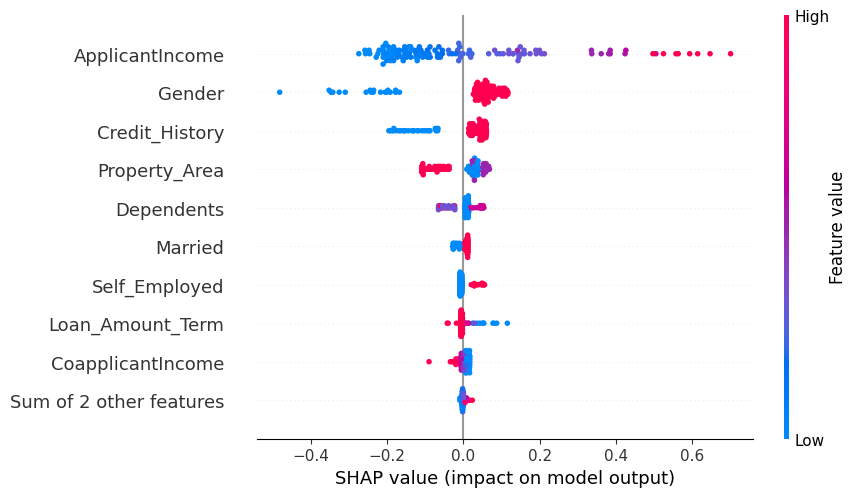

In [10]:
# Beeswarm plot
shap.plots.beeswarm(shap_values[:, :, 1])


### **Question 3b. Which feature appears to be the most important across all data points? Are there any features that have a mixed effect (i.e. pushing predictions towards class 1 and other times pushing them away?) What could cause this variability? How do the color of the dots help you interpret the relationship between the feature value and the prediction? Are there any notable findings?**

**Which feature appears to be the most important across all data points?**

ApplicantIncome is the most important feature globally. In a SHAP beeswarm plot, the features are ranked on the y-axis from most influential to least influential. ApplicantIncome sits at the very top, and its dots stretch furthest horizontally, meaning it exerts the largest overall impact (both positive and negative) on the model's predictions across the entire dataset.

**Are there any features that have a mixed effect (i.e. pushing predictions towards class 1 and other times pushing them away?) What could cause this variability?**

Yes, almost all the top features have a mixed effect, appearing on both the left side (pushing toward denial/class 0) and the right side (pushing toward approval/class 1) of the center zero-line.

This variability is directly caused by the actual value of the feature for each specific applicant. For example, a high value in a specific category might help an applicant, while a low value in that exact same category hurts them. The model does not just look at the category itself; it dynamically adjusts the score based on the specific number the applicant brings to the table.

**How do the color of the dots help you interpret the relationship between the feature value and the prediction?**

The color acts as the legend for the raw data: Red indicates a high feature value, and Blue indicates a low feature value. This allows you to immediately see the directional relationship (correlation) between the data and the outcome:

Positive Relationship: Look at Credit_History. All the red dots (good credit) are grouped on the right (increasing approval probability), while the blue dots (bad credit) are strictly on the left (decreasing approval probability).

Negative Relationship: Look at Loan_Amount_Term. The red dots (longer loan terms) actually push the prediction slightly to the left (decreasing approval odds), while the blue dots (shorter loan terms) push it to the right.

**Are there any notable findings?**

The most notable—and highly concerning—finding is the global behavior of the Gender variable.

Sitting as the second most important feature overall, it can be clearly seen a dense cluster of red dots (which, based on lambda function, represents Male = 1) sitting entirely on the positive side of the center line. Conversely, the blue dots (Female = 0) are stretched far out onto the negative side.

This visual mathematically proves that the model's biased behavior isn't just an isolated incident for one specific applicant; the algorithm has systematically learned to penalize female applicants globally, artificially lowering their chances of approval strictly based on their demographic group. This is a massive red flag for algorithmic fairness!

## **Part 4: Ethical Reflection**


As you explored the SHAP plots, you were able to see how individual featuers contribute to a model's predictions, increasing transparency. However, even with these interpretability tools, there are broader ethical concerns regarding bias and transparency in machine learning systems.

Machine learning models, particularly those used in high-stakes areas like healthcare, finance, and criminal justice, can inadvertently reinforce societal biases present in the training data (e.g., based on race, gender, income). While tools like SHAP provide insights into how models make decisions, they do not prevent biased outcomes.





**Question 1: How can explainability tools such as SHAP help identify bias in machine learning models?**

Explainability tools like SHAP act as a diagnostic x-ray for machine learning algorithms. They help identify bias by forcing the model to mathematically justify its decisions, preventing discriminatory logic from hiding behind a high overall accuracy score.

For example, if you only looked at the 91% accuracy of your loan model, you might have deployed it assuming it was perfectly fair. However, SHAP revealed the exact numerical weight the model gave to every feature. By visualizing these weights globally (like in the beeswarm plot) and locally (like in the force plot), you were able to spot that the model had learned to heavily penalize female applicants simply based on the Gender variable. SHAP shifts bias from a vague suspicion into mathematical proof, allowing data scientists to identify and remove discriminatory patterns learned from imbalanced historical data before the model impacts real human lives.


**Question 2: How does explainability contribute to transparency in machine learning systems?**

Transparency in machine learning means transforming a model from a "black box" that simply spits out a final answer into a "glass box" that explains why it reached that conclusion. Explainability contributes to this by providing a clear, human-readable audit trail of the algorithm's decision-making process.

In high-stakes industries like finance, criminal justice, or healthcare, this level of transparency is essential for three major reasons:

Accountability and Trust: It allows stakeholders, regulators, and the general public to verify that decisions are being made logically and ethically, rather than arbitrarily.

Regulatory Compliance: Many laws (such as the Equal Credit Opportunity Act in the US) legally require institutions to provide specific reasons for adverse actions, such as denying a loan. Explainability tools make it possible to comply with these legal standards.

Actionable Recourse: Instead of just telling an applicant "the computer said no," transparency allows institutions to provide constructive feedback. If a model explains that a loan was denied primarily due to a short Loan_Amount_Term or low Credit_History, the applicant is given a clear, actionable path to improve their circumstances for the future.